# 🏡 House Price Prediction using Supervised Learning

## 📌 Project Overview

This notebook presents an end-to-end supervised machine learning workflow for predicting residential house prices using the Ames Housing Dataset. The project includes data exploration, preprocessing, feature engineering, regression model development, hyperparameter tuning, model evaluation, interpretation, and pipeline serialization for deployment. Multiple regression algorithms are implemented and compared to identify the most accurate model for house price prediction.

Five regression algorithms are implemented and compared:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- XGBoost Regressor

The final model is selected based on predictive performance using RMSE, MAE, R² Score, and Cross-Validation. The trained pipeline is saved using Joblib for future deployment through a Streamlit web application.

---

## 🎯 Objective

The primary objective of this project is to build a robust regression model capable of accurately estimating house prices based on property characteristics. The workflow involves:

- Performing Exploratory Data Analysis (EDA)
- Handling missing values and outliers
- Engineering meaningful features
- Training and comparing multiple regression models
- Optimizing the best-performing model
- Interpreting predictions using Feature Importance and SHAP values
- Saving the final pipeline for deployment

In [101]:
# ==========================
# Import Libraries
# ==========================

import warnings
warnings.filterwarnings("ignore")

import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

# Scikit-Learn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# XGBoost
from xgboost import XGBRegressor

import shap

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


---
# 🧠 Step 1: Problem Framing & Theory Notes

## 1. What is Regression? How is it different from Classification?

### Regression
- Regression is a supervised learning technique used to predict continuous numerical values.
- The target variable is numeric (e.g., house price, salary, temperature).

### Classification
- Classification predicts categorical labels or classes.
- The target variable is discrete (e.g., Spam/Not Spam, Pass/Fail).

### Real-World Indian Examples
- Predicting home prices on NoBroker or MagicBricks.
- Predicting crop yield for farmers in Maharashtra.
---

## 2. Difference between Simple, Multiple & Regularized Regression

### Simple Linear Regression
- Uses one independent feature to predict the target.
- Example: House Price based only on Area.

### Multiple Linear Regression
- Uses multiple independent features.
- Example: Area, Bedrooms, Location, Age of House.

### Regularized Regression (Ridge & Lasso)
- Reduces overfitting by adding a penalty to model coefficients.
- Ridge (L2) shrinks coefficients, while Lasso (L1) can reduce some coefficients to zero for feature selection.
---

## 3. Overfitting vs Underfitting

### Overfitting
- Model learns training data too well, including noise.
- High training accuracy but poor testing performance.

### Underfitting
- Model is too simple to capture patterns.
- Performs poorly on both training and testing data.

### How Regularization Helps
- L1 and L2 penalties reduce model complexity.
- Improves generalization on unseen data.
---

## 4. RMSE, MAE & R² Score

### RMSE (Root Mean Squared Error)
- Measures prediction error with higher penalty for large errors.

### MAE (Mean Absolute Error)
- Measures average absolute prediction error.
- Less sensitive to outliers.

### R² Score
- Indicates how well the model explains the variance in the target variable.
- Values closer to 1 indicate better performance.

### When to Prefer RMSE?
- When large prediction errors should be penalized more heavily.
---

## 5. What is Cross-Validation?

- Cross-validation divides the dataset into multiple folds.
- The model is trained and tested on different folds repeatedly.
- Provides a more reliable estimate of model performance than a single train-test split.
- Reduces the risk of overfitting and improves model evaluation.
---

# 📂 Step 2: Dataset Loading & Exploratory Data Analysis (EDA)

## 2.1 Load & Understand the Dataset

In [3]:
# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("../data/train.csv")

print("Dataset Loaded Successfully! ✅")

Dataset Loaded Successfully! ✅


In [4]:
# ==========================
# Basic Information
# ==========================

print("Shape of Dataset:", df.shape)

print("\nDataset Information:\n")
df.info()

print("\nStatistical Summary:\n")
display(df.describe())

Shape of Dataset: (1460, 81)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# ==========================
# Dataset Overview
# ==========================

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

missing_cols = df.columns[df.isnull().sum() > 0]

print(f"Total Columns              : {df.shape[1]}")
print(f"Numerical Columns          : {len(numerical_cols)}")
print(f"Categorical Columns        : {len(categorical_cols)}")
print(f"Columns with Missing Values: {len(missing_cols)}")

Total Columns              : 81
Numerical Columns          : 38
Categorical Columns        : 43
Columns with Missing Values: 19


In [6]:
# ==========================
# Missing Value Summary
# ==========================

missing_summary = (df.isnull().sum().reset_index())
missing_summary.columns = ["Column", "Missing Values"]
missing_summary["Missing %"] = (missing_summary["Missing Values"] / len(df) * 100)
missing_summary = (missing_summary[missing_summary["Missing Values"] > 0].sort_values("Missing %", ascending=False))

display(missing_summary)

,Column,Missing Values,Missing %
72,PoolQC,1453,99.520548
74,MiscFeature,1406,96.301370
6,Alley,1369,93.767123
73,Fence,1179,80.753425
25,MasVnrType,872,59.726027
57,FireplaceQu,690,47.260274
3,LotFrontage,259,17.739726
58,GarageType,81,5.547945
59,GarageYrBlt,81,5.547945
60,GarageFinish,81,5.547945


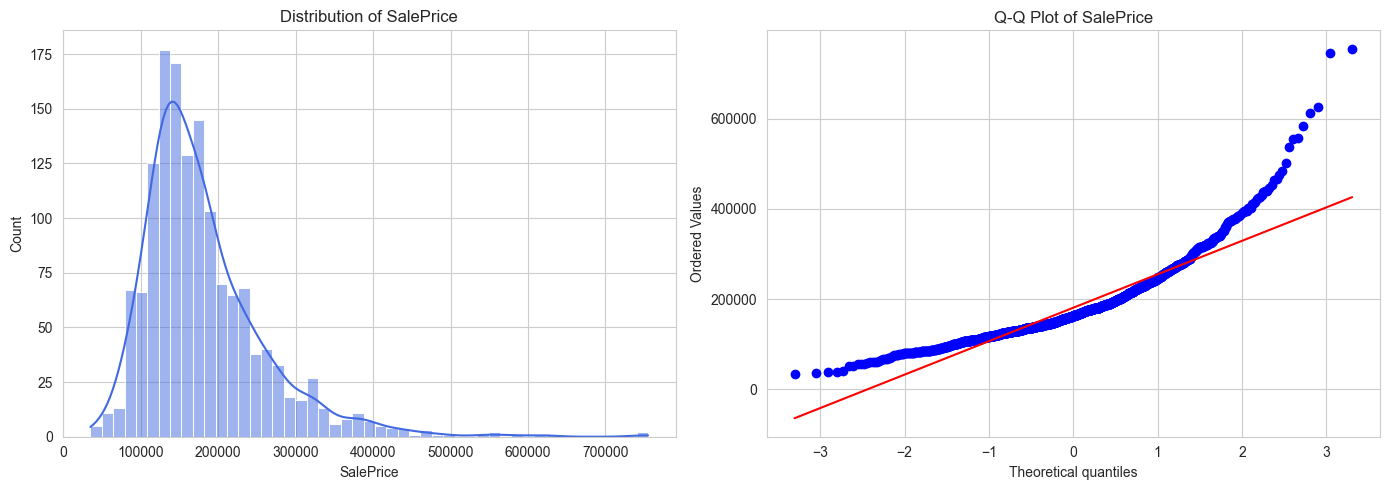

In [7]:
# ==========================
# Distribution of SalePrice
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Distribution of SalePrice")
axes[0].set_xlabel("SalePrice")

# Q-Q Plot
stats.probplot(df["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of SalePrice")

plt.tight_layout()
plt.savefig("../reports/figures/saleprice_distribution_before_log.png", dpi=300, bbox_inches="tight")   
plt.show()

### 📌 Interpretation

- The original **SalePrice** distribution is positively skewed with a long right tail.
- The Q-Q plot indicates that the data deviates from a normal distribution, especially in the upper tail.
- After applying the **log1p transformation**, the distribution becomes much more symmetric.
- The transformed Q-Q plot shows points aligning more closely with the reference line, indicating improved normality.
- Therefore, the log-transformed target variable will be used for building regression models.

In [8]:
# ==========================
# Log Transformation
# ==========================

df["SalePrice_Log"] = np.log1p(df["SalePrice"])

print("Log Transformation Applied Successfully ✅")

Log Transformation Applied Successfully ✅


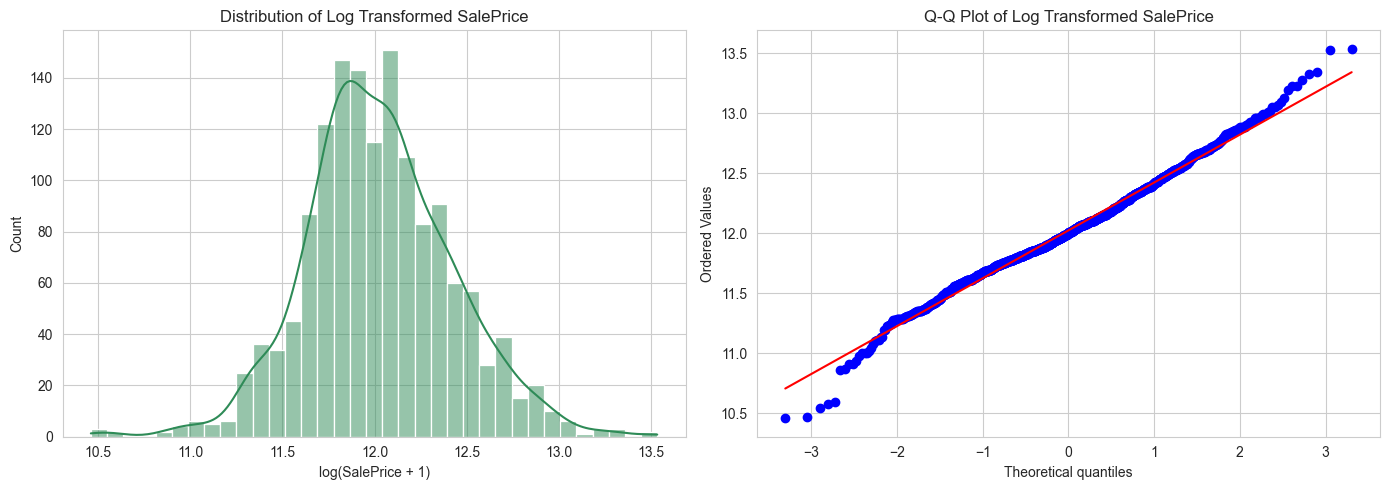

In [9]:
# ==========================
# Distribution after log1p
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df["SalePrice_Log"], kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Distribution of Log Transformed SalePrice")
axes[0].set_xlabel("log(SalePrice + 1)")

# Q-Q Plot
stats.probplot(df["SalePrice_Log"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Log Transformed SalePrice")

plt.tight_layout()
plt.savefig("../reports/figures/saleprice_distribution_after_log.png", dpi=300, bbox_inches="tight")
plt.show()

### 📌 Interpretation (After log1p Transformation)

- The **log1p transformation** significantly reduces the right skewness of the `SalePrice` distribution.
- The histogram appears more symmetric and closely resembles a normal distribution.
- In the Q-Q plot, most data points lie near the reference line, indicating improved normality.
- This transformation helps satisfy the assumptions of many regression models and can improve model performance.
- Therefore, the **log-transformed SalePrice** will be used as the target variable during model training.

## 2.2 Univariate Analysis

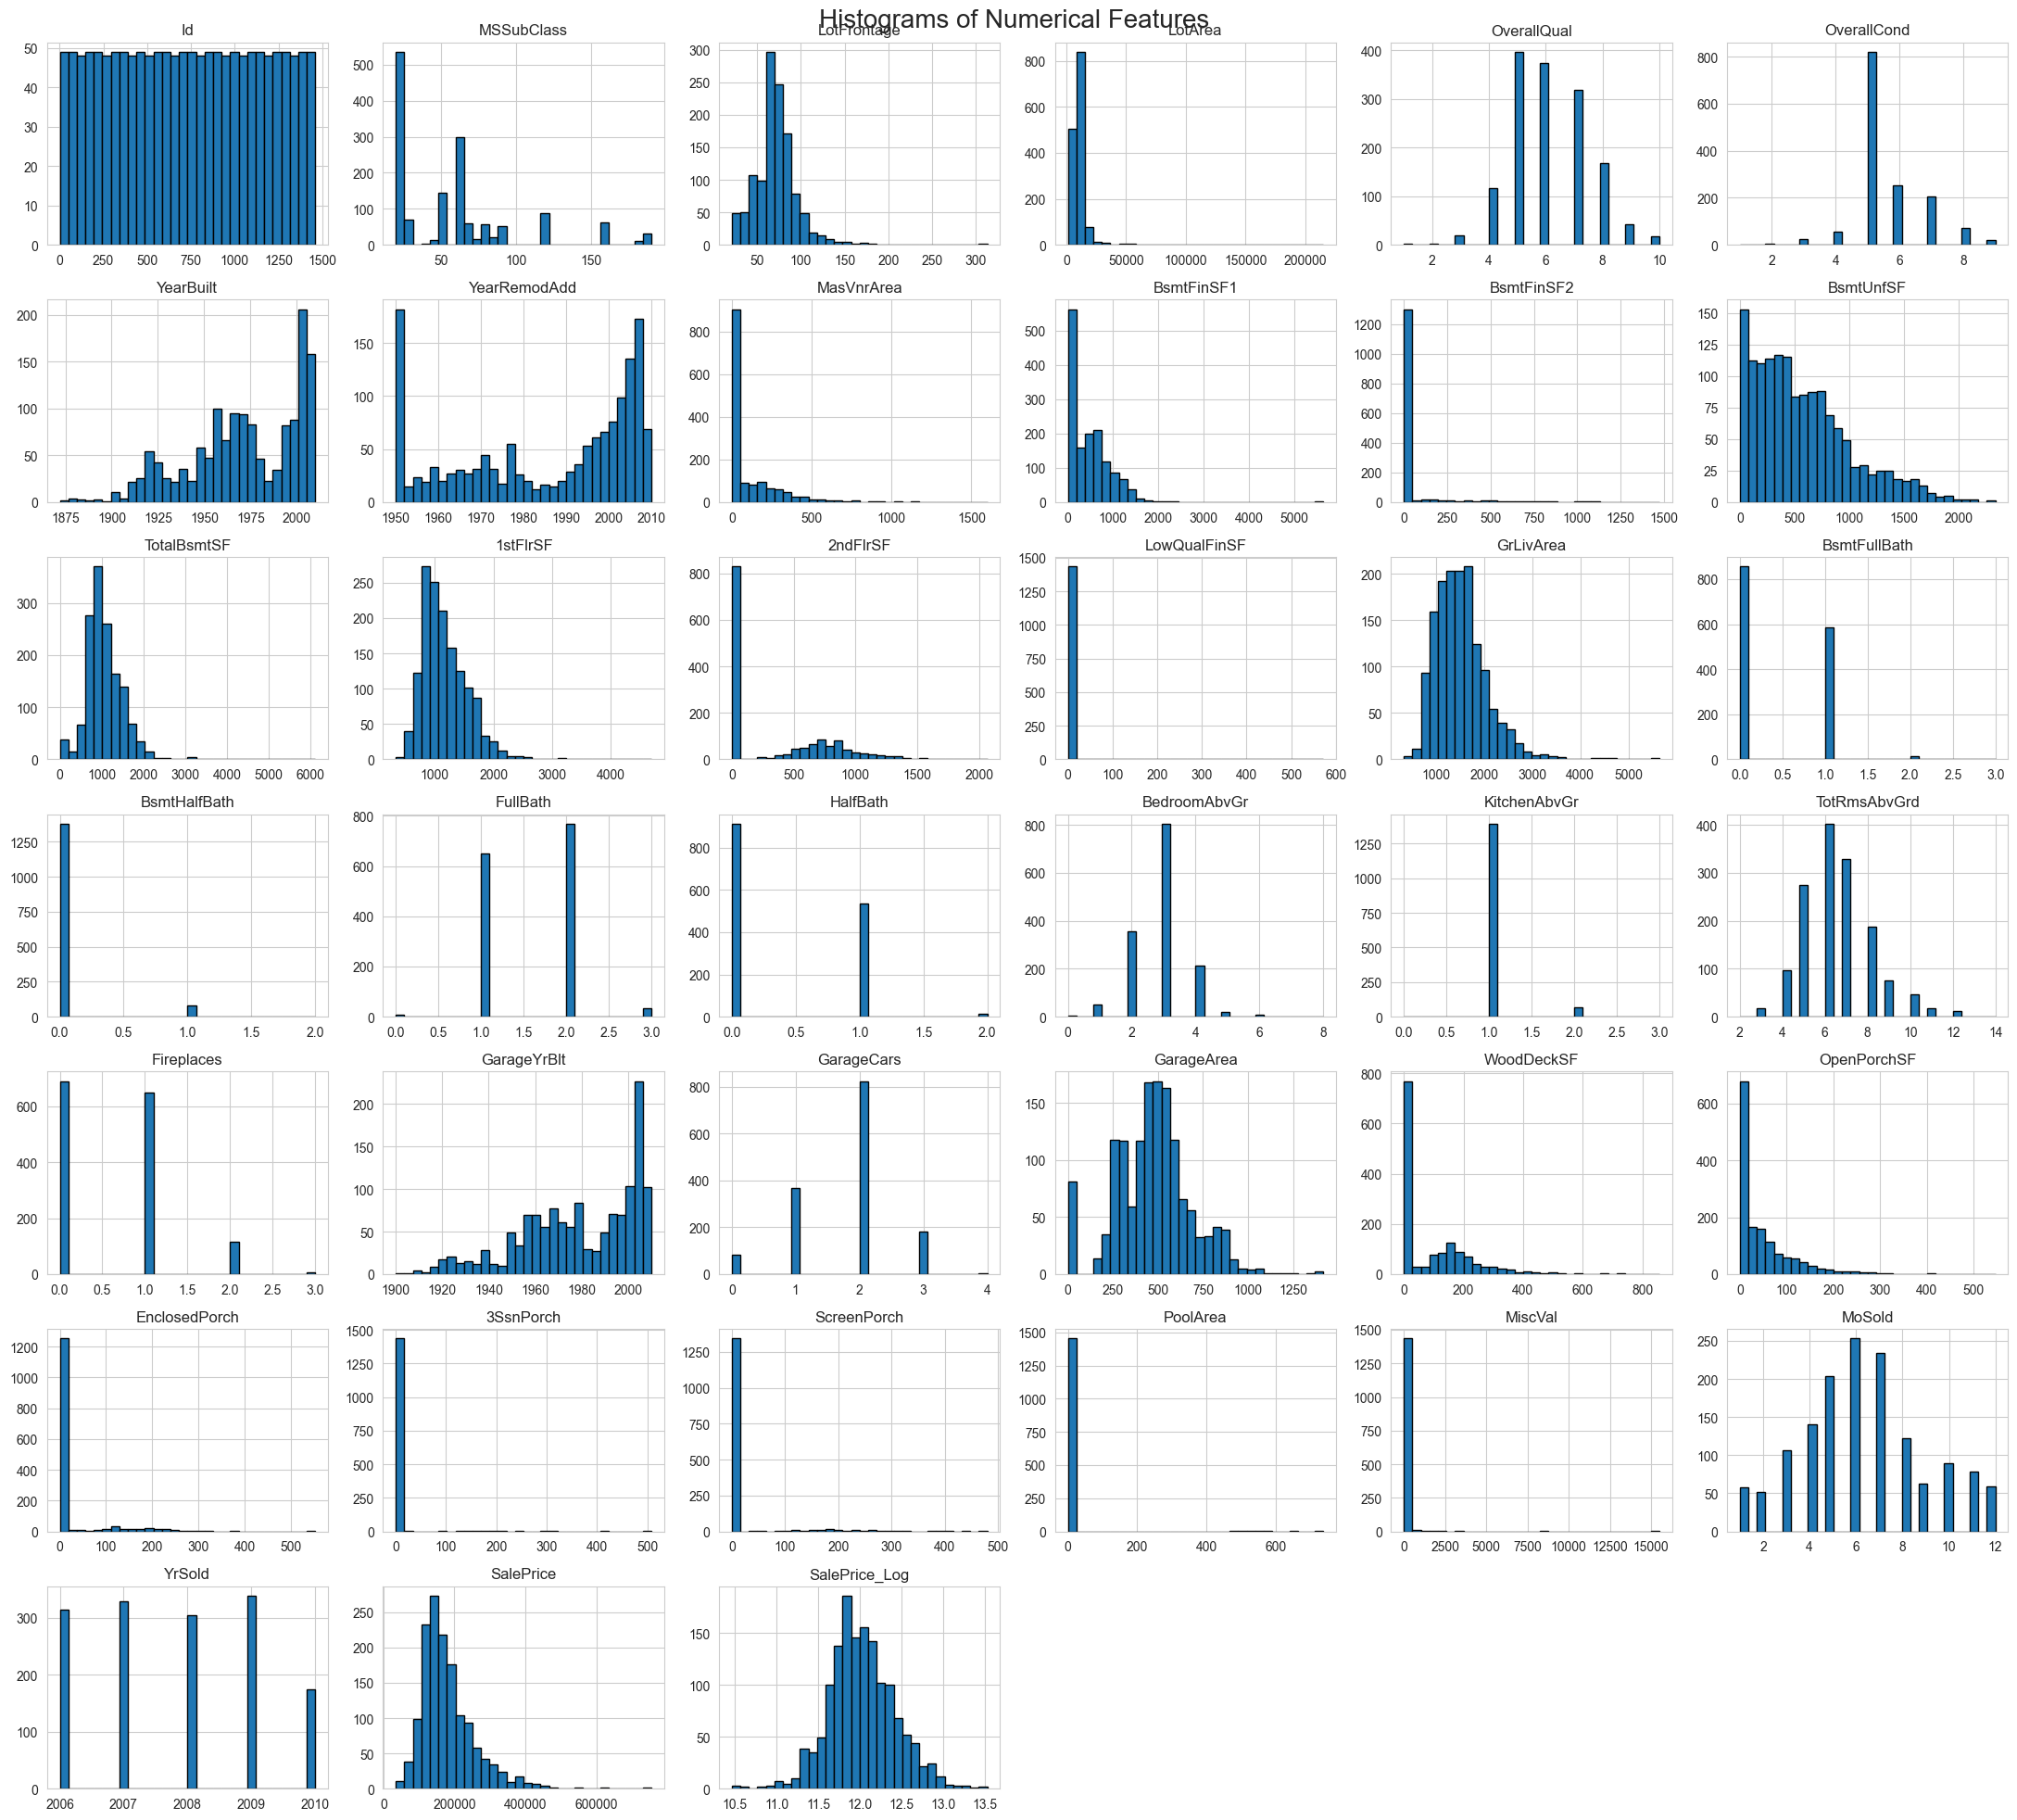

Top 5 Most Skewed Numerical Features



,Skewness
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341


In [10]:
# ==========================
# Histograms of Numerical Features
# ==========================

# Select numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Plot histograms
df[num_cols].hist(figsize=(22, 20), bins=30, edgecolor="black")

plt.suptitle("Histograms of Numerical Features", fontsize=20)
plt.tight_layout()
plt.savefig("../reports/figures/numerical_features_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


# ==========================
# Top 5 Most Skewed Features
# ==========================

skewness = (df[num_cols].skew().sort_values(ascending=False))

top5_skewed = skewness.head(5)

print("Top 5 Most Skewed Numerical Features\n")
display(top5_skewed.to_frame(name="Skewness"))

### 📌 Interpretation

- Histograms show that numerical features have different distributions, with many exhibiting positive skewness.
- Several variables are not normally distributed, indicating the presence of long right tails.
- The top 5 most skewed features may require transformation (such as log1p) during preprocessing.
- Understanding feature distributions helps in selecting suitable preprocessing techniques before model training.

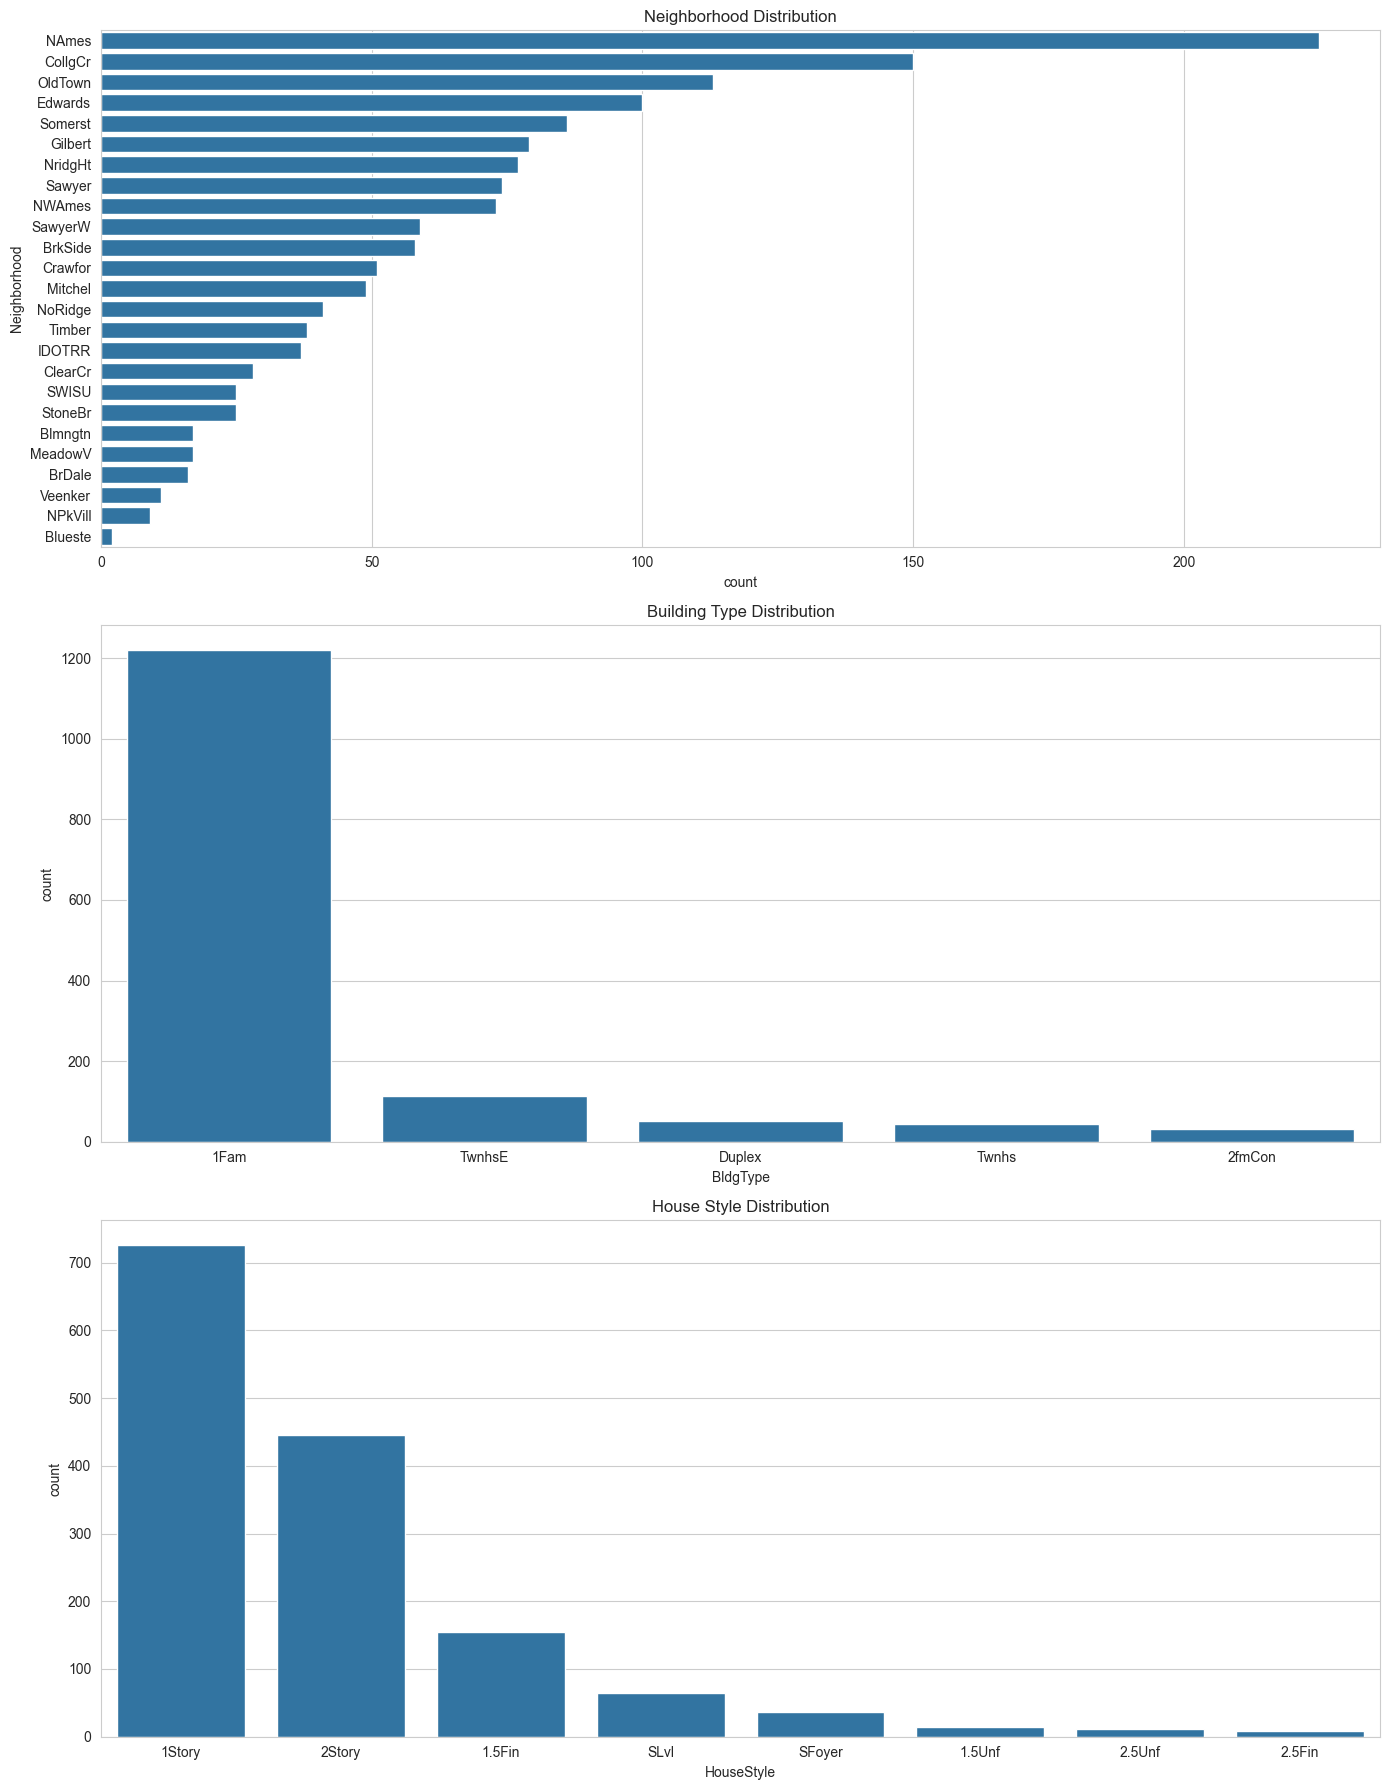

In [11]:
# ==========================
# Countplots for Important Categorical Features
# ==========================

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

sns.countplot(data=df, y="Neighborhood", order=df["Neighborhood"].value_counts().index, ax=axes[0])
axes[0].set_title("Neighborhood Distribution")

sns.countplot(data=df, x="BldgType", order=df["BldgType"].value_counts().index, ax=axes[1])
axes[1].set_title("Building Type Distribution")

sns.countplot(data=df, x="HouseStyle", order=df["HouseStyle"].value_counts().index, ax=axes[2])
axes[2].set_title("House Style Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/categorical_countplots.png", dpi=300, bbox_inches="tight")
plt.show()

### 📌 Interpretation

- The **Neighborhood** feature shows an uneven distribution, with some neighborhoods having significantly more houses than others.
- Most properties belong to the **1Fam** building type, indicating it is the dominant residential category.
- The **1Story** and **2Story** house styles are the most common, while other styles occur less frequently.
- These categorical distributions provide useful insights into the composition of the housing dataset and may influence house prices.

## 2.3 Bivariate Analysis

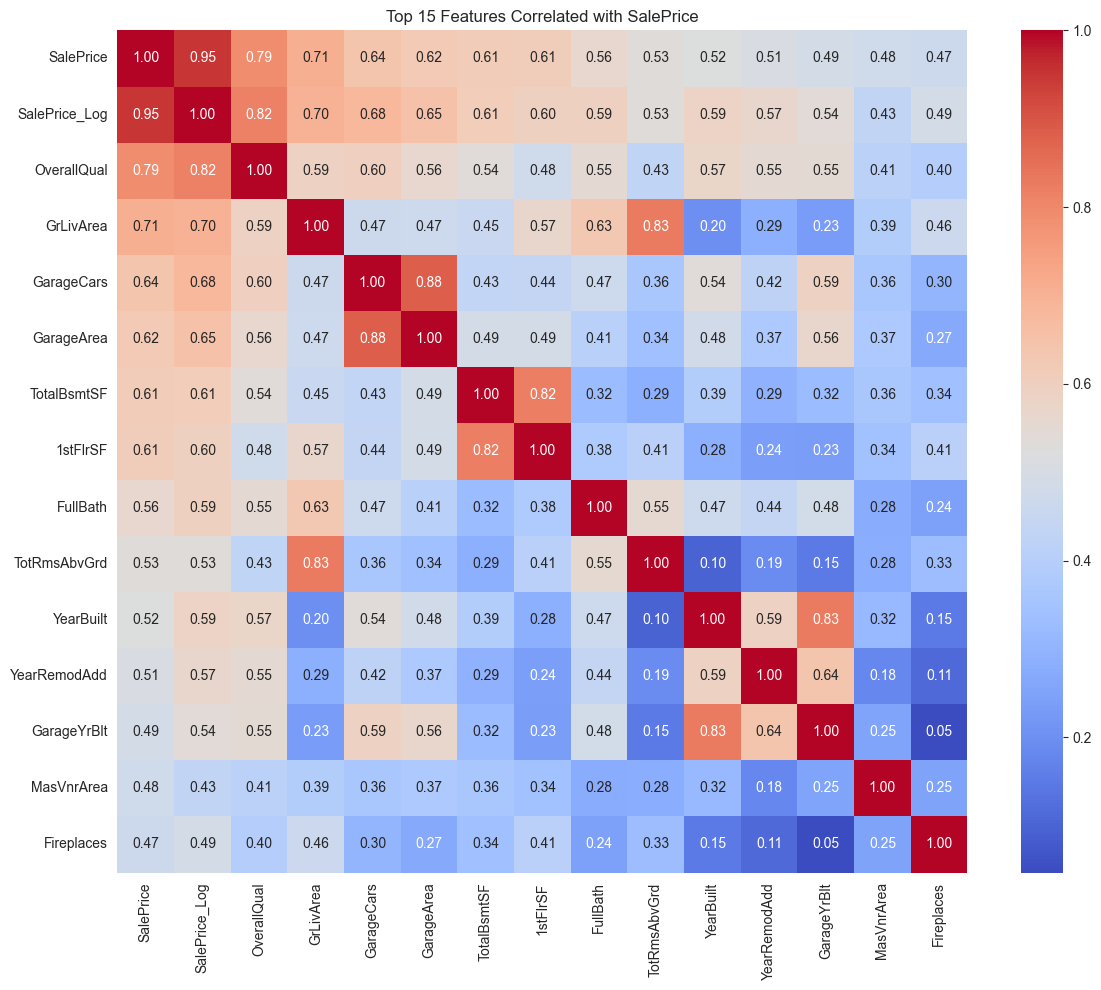

In [12]:
# ==========================
# Correlation Heatmap
# ==========================

corr = df.corr(numeric_only=True)

top15_features = (corr["SalePrice"].abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(12, 10))

sns.heatmap(df[top15_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Top 15 Features Correlated with SalePrice")
plt.tight_layout()
plt.savefig("../reports/figures/top15_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 📌 Interpretation

- The heatmap highlights the strongest relationships with **SalePrice**.
- Features such as **OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF,** and **1stFlrSF** show strong positive correlations.
- These highly correlated features are expected to play an important role in predicting house prices.

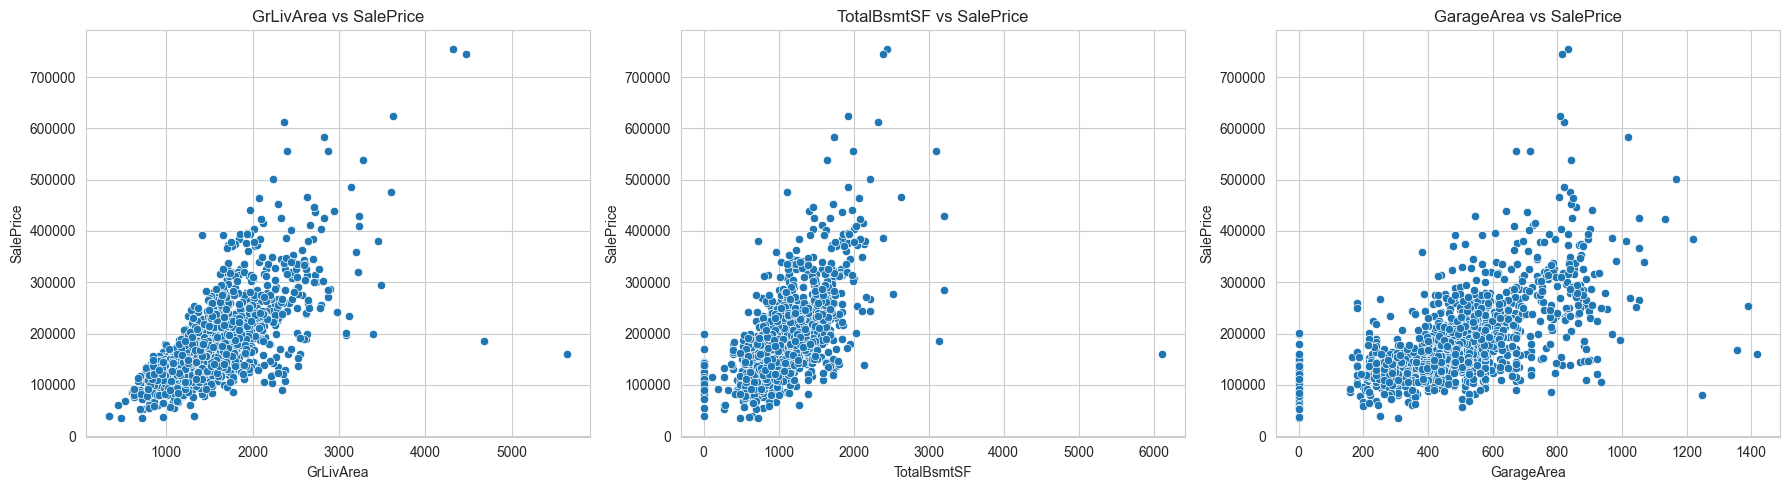

In [13]:
# ==========================
# Scatter Plots
# ==========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", ax=axes[0])
axes[0].set_title("GrLivArea vs SalePrice")

sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice", ax=axes[1])
axes[1].set_title("TotalBsmtSF vs SalePrice")

sns.scatterplot(data=df, x="GarageArea", y="SalePrice", ax=axes[2])
axes[2].set_title("GarageArea vs SalePrice")

plt.tight_layout()
plt.savefig("../reports/figures/scatterplots_saleprice.png", dpi=300, bbox_inches="tight")
plt.show()

### 📌 Interpretation

- Larger living area (**GrLivArea**) generally leads to higher house prices.
- Houses with larger basements (**TotalBsmtSF**) also tend to have higher sale prices.
- **GarageArea** has a positive relationship with SalePrice, although a few scattered observations are present.
- Overall, these variables show strong positive relationships with the target variable.

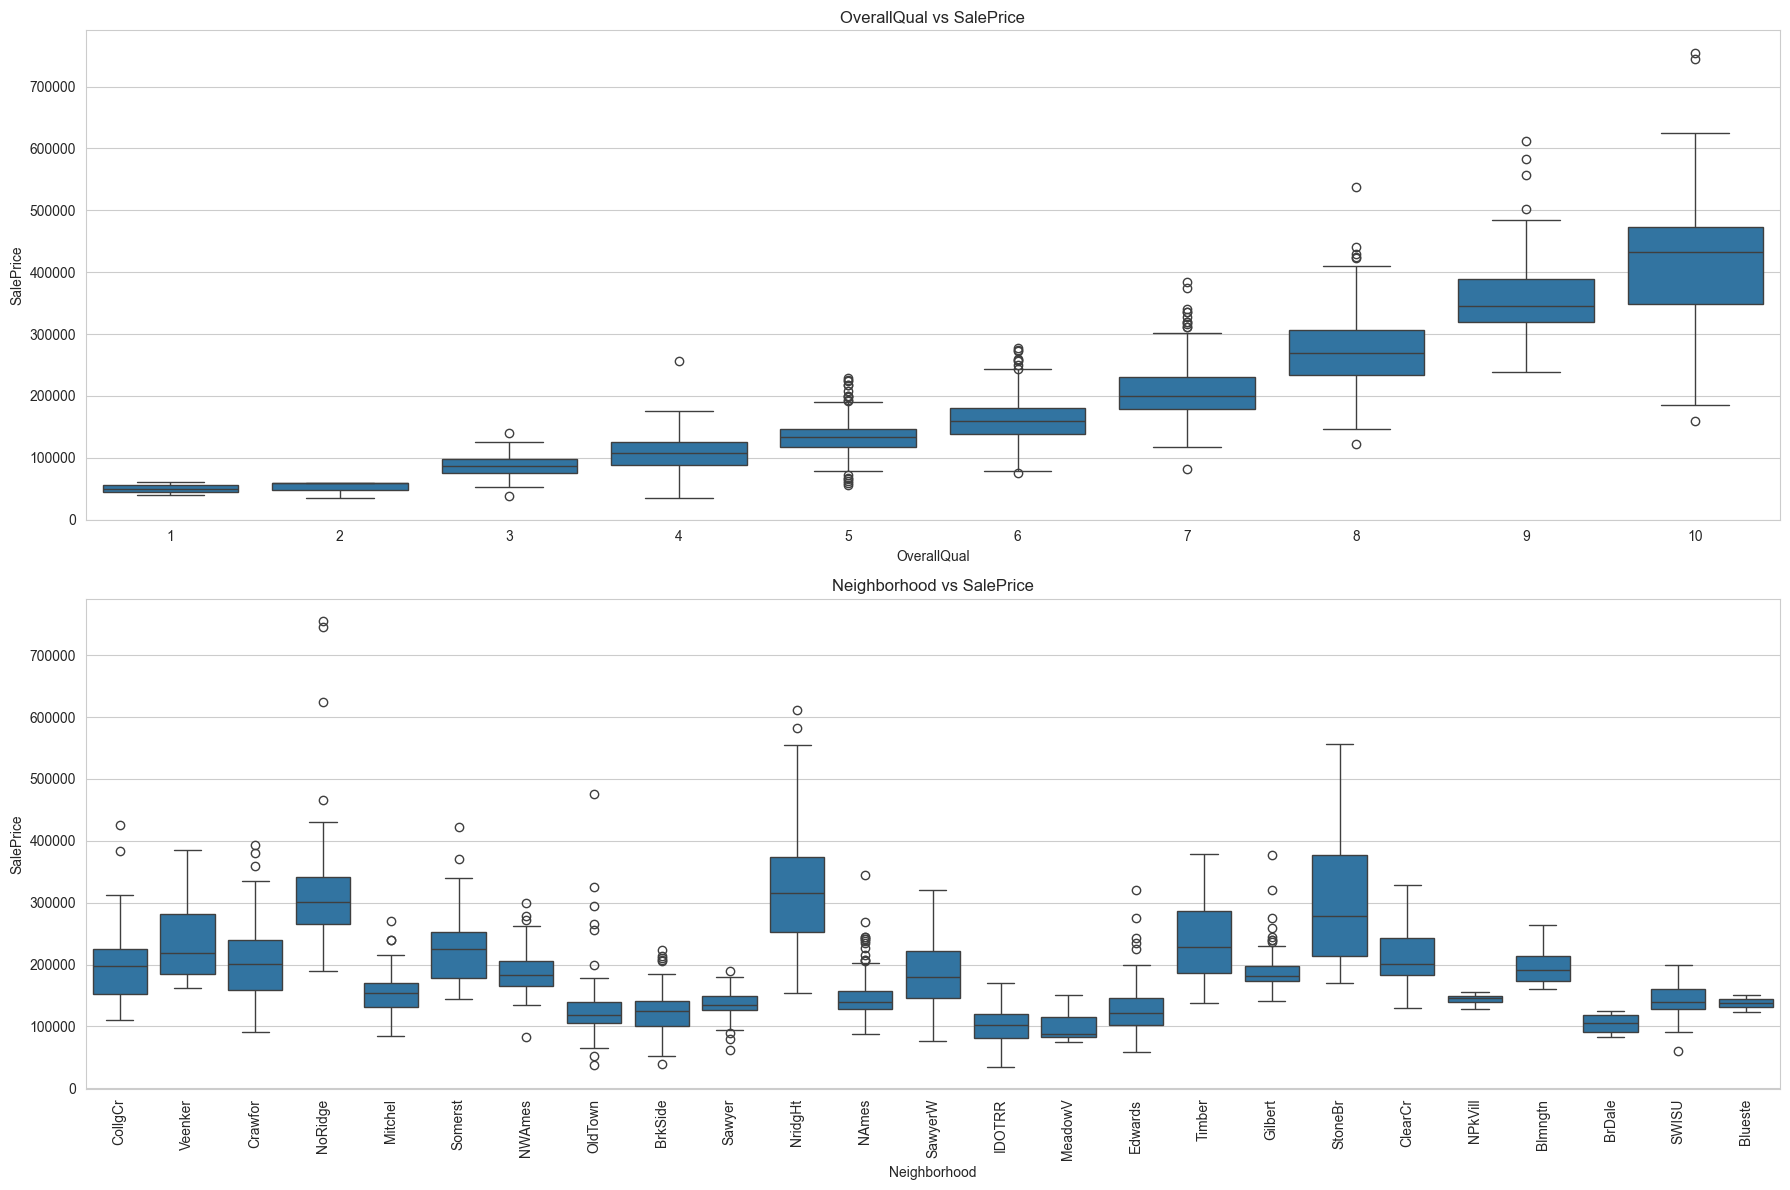

In [14]:
# ==========================
# Boxplots
# ==========================

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice",
    ax=axes[0]
)

axes[0].set_title("OverallQual vs SalePrice")

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice",
    ax=axes[1]
)

axes[1].tick_params(axis="x", rotation=90)
axes[1].set_title("Neighborhood vs SalePrice")

plt.tight_layout()

plt.savefig(
    "../reports/figures/boxplots_saleprice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Houses with higher **OverallQual** receive significantly higher sale prices.
- Sale prices vary considerably across different neighborhoods.
- Premium neighborhoods generally have higher median prices than others, indicating that location strongly influences house prices.

In [15]:
# ==========================
# Most Expensive Neighborhood
# ==========================

neighborhood_price = (
    df.groupby("Neighborhood")["SalePrice"]
      .median()
      .sort_values(ascending=False)
)

print("Median SalePrice by Neighborhood\n")

display(neighborhood_price)

print(f"\nMost Expensive Neighborhood: {neighborhood_price.index[0]}")

Median SalePrice by Neighborhood



Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


Most Expensive Neighborhood: NridgHt


### 📌 Interpretation

- Based on the median sale price, the neighborhood printed above is the most expensive in the dataset.
- This indicates that location is one of the strongest factors affecting house prices.

Potential Outliers:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


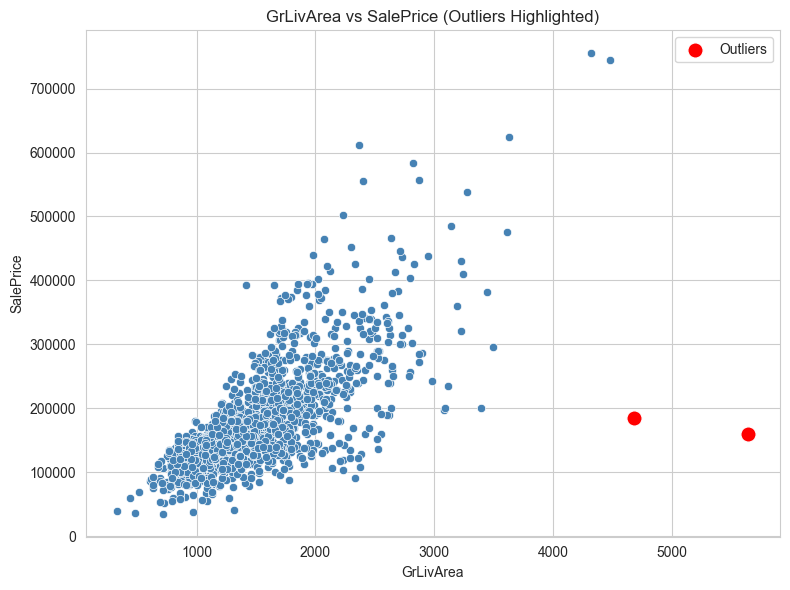

In [16]:
# ==========================
# Outlier Detection
# ==========================

outliers = df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
]

print("Potential Outliers:")

display(outliers[["Id", "GrLivArea", "SalePrice"]])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    color="steelblue"
)

sns.scatterplot(
    data=outliers,
    x="GrLivArea",
    y="SalePrice",
    color="red",
    s=120,
    label="Outliers"
)

plt.title("GrLivArea vs SalePrice (Outliers Highlighted)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/outliers_grlivarea.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Two houses have exceptionally large living areas (**GrLivArea > 4000**) but unusually low sale prices.
- These observations behave differently from the overall trend and are considered outliers.
- Such outliers can negatively affect linear regression by pulling the regression line away from the majority of observations.
- These records will be removed during the preprocessing stage as instructed in the practical exam.

---

# 🔧 Step 3: Data Preprocessing & Feature Engineering

## 3.1 Handle Missing Values

In [17]:
# ==========================
# Missing Value Report
# ==========================

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_report = (
    missing_report[missing_report["Missing Values"] > 0]
    .sort_values(by="Missing Percentage", ascending=False)
)

display(missing_report)

,Missing Values,Missing Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### 📌 Interpretation

- Several columns contain missing values with varying percentages.
- Some missing values represent the absence of a feature (e.g., no garage or no pool), while others require statistical imputation.
- These missing values will be handled using different strategies based on feature meaning.

In [18]:
# ==========================
# Fill Categorical Missing Values
# ==========================

none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",
    "MasVnrType"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

print("Categorical missing values filled with 'None'.")

Categorical missing values filled with 'None'.


In [19]:
# ==========================
# Fill Numerical Missing Values with 0
# ==========================

zero_cols = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print("Numerical missing values filled with 0.")

Numerical missing values filled with 0.


In [20]:
# ==========================
# Fill Remaining Numerical Missing Values
# ==========================

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Remaining numerical missing values filled with median.")

Remaining numerical missing values filled with median.


In [21]:
# Fill remaining categorical missing values with mode

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining categorical missing values filled with mode.")

Remaining categorical missing values filled with mode.


In [22]:
# ==========================
# Drop Columns with >80% Missing Values
# ==========================

missing_percent = df.isnull().mean() * 100

drop_cols = missing_percent[missing_percent > 80].index

print("Dropped Columns:")
print(list(drop_cols))

df.drop(columns=drop_cols, inplace=True)

print("\nRemaining Shape:", df.shape)

Dropped Columns:
[]

Remaining Shape: (1460, 82)


In [23]:
# ==========================
# Verify Missing Values
# ==========================

remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

print(f"Remaining Columns with Missing Values: {len(remaining_missing)}")

if len(remaining_missing) > 0:
    display(remaining_missing)
else:
    print("No Missing Values Remaining ✅")

Remaining Columns with Missing Values: 0
No Missing Values Remaining ✅


## 3.2 Outlier Removal

In [24]:
# ==========================
# Remove Outliers
# ==========================

print("Shape Before Removing Outliers:", df.shape)

# Remove the two extreme outliers
df = df.drop(
    df[
        (df["GrLivArea"] > 4000) &
        (df["SalePrice"] < 300000)
    ].index
)

print("Shape After Removing Outliers:", df.shape)

Shape Before Removing Outliers: (1460, 82)
Shape After Removing Outliers: (1458, 82)


In [25]:
# ==========================
# Verify Outlier Removal
# ==========================

remaining_outliers = df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
]

print("Remaining Outliers:", len(remaining_outliers))

display(remaining_outliers)

Remaining Outliers: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_Log


### 📌 Interpretation

- Two extreme outlier observations with unusually large living areas but relatively low sale prices were removed from the dataset.
- These points do not follow the general relationship between **GrLivArea** and **SalePrice**.
- Such outliers can disproportionately influence the regression line, resulting in biased model coefficients and reduced prediction accuracy.
- Removing these observations improves the model's ability to learn the true relationship between house size and sale price.

## 3.3 Feature Engineering

In [26]:
# ==========================
# Feature Engineering
# ==========================

# Total Usable Area
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

# House Age
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Years Since Last Remodeling
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

# Garage Indicator
df["HasGarage"] = np.where(df["GarageArea"] > 0, 1, 0)

# Pool Indicator
df["HasPool"] = np.where(df["PoolArea"] > 0, 1, 0)

print("Feature Engineering Completed Successfully! ✅")

display(
    df[[
        "TotalSF",
        "HouseAge",
        "RemodAge",
        "HasGarage",
        "HasPool"
    ]].head()
)

Feature Engineering Completed Successfully! ✅


,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


### 📌 Interpretation

- New features were created to better represent the characteristics of each property.
- **TotalSF** captures the total usable living space by combining basement, first-floor, and second-floor areas.
- **HouseAge** and **RemodAge** represent the age of the house and the time since its last renovation.
- **HasGarage** and **HasPool** are binary indicators that capture the presence of these amenities.
- These engineered features can improve the predictive performance of machine learning models by providing more meaningful information than the original variables alone.

## 3.4 Encoding & Scaling

In [27]:
# ==========================
# Ordinal Encoding
# ==========================

# Ordinal mapping for quality-related features
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

ordinal_cols = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "FireplaceQu"
]

# Apply mapping
for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

print("Ordinal Encoding Applied Successfully! ✅")

display(df[ordinal_cols].head())

Ordinal Encoding Applied Successfully! ✅


,ExterQual,KitchenQual,BsmtQual,FireplaceQu
0,4,4,4,0
1,3,3,4,3
2,4,4,4,3
3,3,4,3,4
4,4,4,4,3


In [28]:
# ==========================
# Label Encoding
# ==========================

label_encoder = LabelEncoder()

df["Neighborhood"] = label_encoder.fit_transform(df["Neighborhood"])

print("Label Encoding Applied on Neighborhood! ✅")

display(df[["Neighborhood"]].head())

Label Encoding Applied on Neighborhood! ✅


,Neighborhood
0,5
1,24
2,5
3,6
4,15


In [29]:
# ==========================
# Identify Columns for One-Hot Encoding
# ==========================

# Nominal categorical columns with <= 10 unique values
onehot_cols = [
    col for col in df.select_dtypes(include="object").columns
    if df[col].nunique() <= 10
]

print("Columns selected for One-Hot Encoding:\n")
print(onehot_cols)

Columns selected for One-Hot Encoding:

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [30]:
# ==========================
# Identify Highly Skewed Features
# ==========================

# Continuous numerical columns
continuous_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("SalePrice")

# Calculate skewness
skewness = df[continuous_cols].skew()

# Features with skewness > 0.75
skewed_features = skewness[skewness > 0.75].sort_values(ascending=False)

print(f"Number of Skewed Features: {len(skewed_features)}\n")

display(skewed_features.to_frame(name="Skewness"))

Number of Skewed Features: 23



,Skewness
MiscVal,24.460085
PoolArea,15.948945
HasPool,15.508026
LotArea,12.573925
3SsnPorch,10.297106
LowQualFinSF,9.004955
KitchenAbvGr,4.484883
BsmtFinSF2,4.251925
ScreenPorch,4.118929
BsmtHalfBath,4.100114


In [31]:
# ==========================
# Log Transformation
# ==========================

for col in skewed_features.index:
    df[col] = np.log1p(df[col])

print("log1p Transformation Applied Successfully! ✅")

log1p Transformation Applied Successfully! ✅


In [32]:
# ==========================
# Define Continuous Features
# ==========================

continuous_features = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col != "SalePrice"
]

print(f"Continuous Features: {len(continuous_features)}")

Continuous Features: 48


In [33]:
# ==========================
# Column Transformer
# ==========================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            onehot_cols
        ),
        (
            "scaler",
            StandardScaler(),
            continuous_features
        )
    ],
    remainder="passthrough"
)

print("ColumnTransformer Created Successfully! ✅")

ColumnTransformer Created Successfully! ✅


In [34]:
# ==========================
# Preprocessing Pipeline
# ==========================

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

print("Preprocessing Pipeline Created Successfully! ✅")

Preprocessing Pipeline Created Successfully! ✅


### 📌 Interpretation

- Quality-related features were encoded using **Ordinal Encoding** to preserve their natural ranking.
- The high-cardinality feature **Neighborhood** was converted into numerical labels using **Label Encoding**.
- Highly skewed numerical features were transformed using **log1p()** to reduce skewness and improve model performance.
- Nominal categorical features will be converted into binary variables through **One-Hot Encoding**, while continuous numerical features will be standardized using **StandardScaler**.
- A **ColumnTransformer** and **Pipeline** were created to ensure that all preprocessing steps are applied consistently and efficiently during model training and prediction.

## 3.5 Train-Test Split

In [35]:
# ==========================
# Define Features & Target
# ==========================

# Features
X = df.drop(columns=["SalePrice", "SalePrice_Log"])

# Target (Log Transformed SalePrice)
y = df["SalePrice_Log"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1458, 85)
Target Shape   : (1458,)


In [36]:
# ==========================
# Train-Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed Successfully! ✅\n")

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

Train-Test Split Completed Successfully! ✅

X_train Shape : (1166, 85)
X_test Shape  : (292, 85)
y_train Shape : (1166,)
y_test Shape  : (292,)


### 📌 Interpretation

- The dataset was divided into **80% training data** and **20% testing data** using `random_state=42` to ensure reproducibility.
- The **log-transformed SalePrice** was used as the target variable to improve normality and model performance.
- The training dataset will be used to train the regression models, while the testing dataset will be used to evaluate their performance on unseen data.

---

# 📐 Step 4: Regression Models

## 4.1 Linear Regression (Baseline)

In [38]:
# ==========================
# Define Continuous Features
# ==========================

continuous_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Continuous Features: {len(continuous_features)}")

Continuous Features: 47


In [41]:
# ==========================
# Column Transformer
# ==========================

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("scaler", StandardScaler(), continuous_features)
    ],
    remainder="drop"
)

In [42]:
# ==========================
# Linear Regression Pipeline
# ==========================

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train model
linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully! ✅")

Linear Regression Model Trained Successfully! ✅


In [43]:
# ==========================
# Model Evaluation
# ==========================

# Predictions (log scale)
y_pred_log = linear_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("=" * 40)
print("Linear Regression Performance")
print("=" * 40)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
RMSE : 23432.14
MAE  : 16117.76
R²   : 0.9006


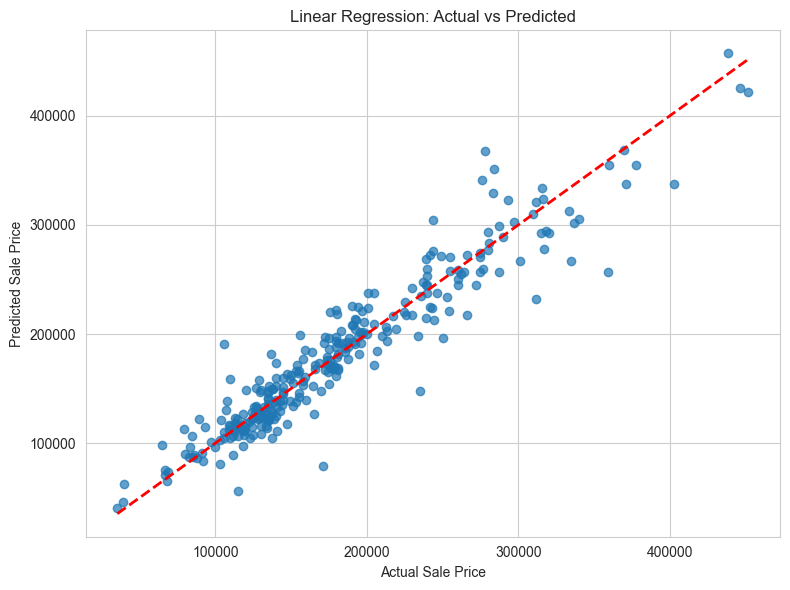

In [45]:
# ==========================
# Actual vs Predicted Plot
# ==========================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.7
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    "../reports/figures/linear_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The Linear Regression model served as the baseline model for predicting house prices.
- The model achieved the above RMSE, MAE, and R² values on the test dataset.
- In the Actual vs Predicted scatter plot, observations closer to the red diagonal line indicate more accurate predictions.
- The spread of points around the diagonal reflects the prediction error, while the overall trend demonstrates how well the linear model captures the relationship between the input features and house prices.

## 4.2 Ridge Regression (L2 Regularization)

In [46]:
# ==========================
# Ridge Regression Pipeline
# ==========================

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
    ]
)

# Train model
ridge_model.fit(X_train, y_train)

print("Ridge Regression Model Trained Successfully! ✅")

Ridge Regression Model Trained Successfully! ✅


In [47]:
# ==========================
# Ridge Regression Evaluation
# ==========================

# Best alpha
best_alpha = ridge_model.named_steps["regressor"].alpha_

print(f"Best Alpha Selected: {best_alpha}")

# Prediction
y_pred_log = ridge_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("\nRidge Regression Performance")
print("-" * 35)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Best Alpha Selected: 10.0

Ridge Regression Performance
-----------------------------------
RMSE : 20547.41
MAE  : 14705.28
R²   : 0.9236


In [48]:
# ==========================
# Top 20 Ridge Coefficients
# ==========================

# Get feature names after preprocessing
feature_names = ridge_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = ridge_model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

top20 = (
    coef_df
    .sort_values("AbsCoefficient", ascending=False)
    .head(20)
)

display(top20)

,Feature,Coefficient,AbsCoefficient
0,onehot__MSZoning_C (all),-0.091029,0.091029
206,scaler__GrLivArea,0.082592,0.082592
192,scaler__OverallQual,0.063841,0.063841
131,onehot__Functional_Typ,0.063234,0.063234
178,onehot__SaleType_New,0.053716,0.053716
1,onehot__MSZoning_FV,0.050456,0.050456
202,scaler__TotalBsmtSF,0.049397,0.049397
193,scaler__OverallCond,0.048735,0.048735
112,onehot__Heating_Grav,-0.046956,0.046956
30,onehot__Condition1_Norm,0.046683,0.046683


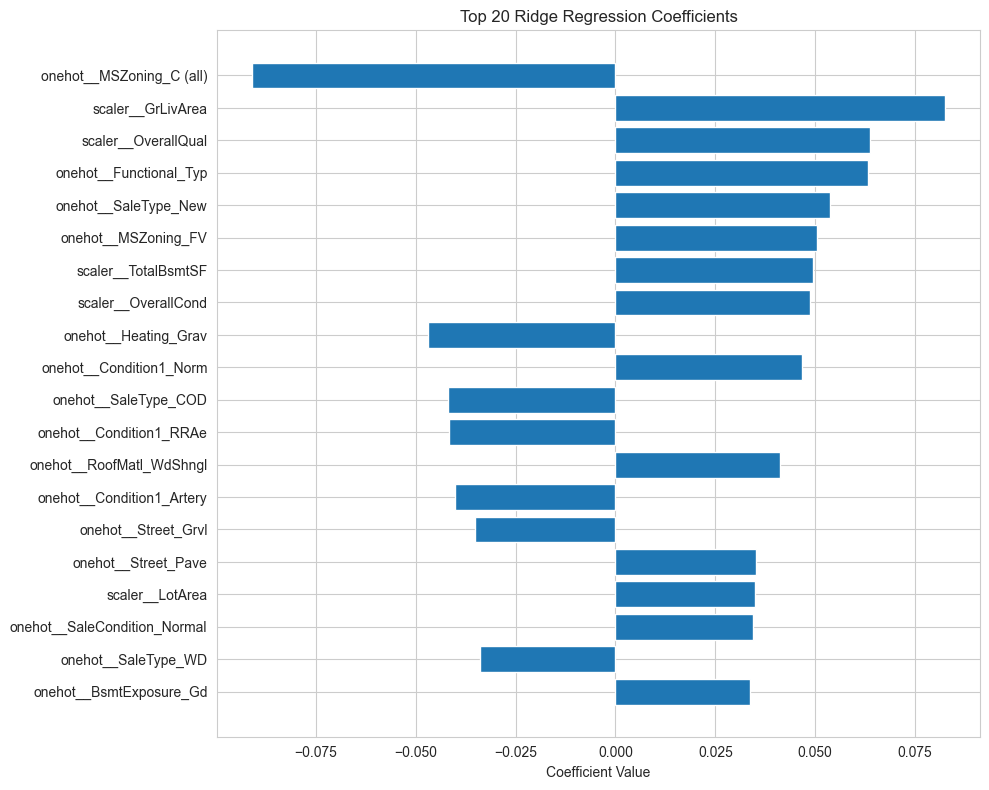

In [49]:
# ==========================
# Plot Top 20 Coefficients
# ==========================

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Coefficient"]
)

plt.title("Top 20 Ridge Regression Coefficients")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/figures/ridge_top20_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Ridge Regression applies **L2 regularization**, which shrinks coefficient magnitudes to reduce overfitting while retaining all features.
- `RidgeCV` automatically selected the optimal regularization strength (`alpha`) from the given values.
- The evaluation metrics (RMSE, MAE, and R²) indicate how well the Ridge model generalizes to unseen data.
- The coefficient plot highlights the **20 most influential features**, showing which variables contribute the most to predicting house prices after regularization.

## 4.3 Lasso Regression (L1 Regularization)

In [50]:
# ==========================
# Lasso Regression Pipeline
# ==========================

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor",
            LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000, random_state=42)
        )])

# Train model
lasso_model.fit(X_train, y_train)

print("Lasso Regression Model Trained Successfully! ✅")

Lasso Regression Model Trained Successfully! ✅


In [51]:
# ==========================
# Lasso Evaluation
# ==========================

# Best Alpha
best_alpha = lasso_model.named_steps["regressor"].alpha_

# Number of zero coefficients
coefficients = lasso_model.named_steps["regressor"].coef_
zero_features = np.sum(coefficients == 0)

print(f"Best Alpha Selected : {best_alpha}")
print(f"Features Zeroed Out : {zero_features}")

# Prediction
y_pred_log = lasso_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("\nLasso Regression Performance")
print("-" * 35)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Best Alpha Selected : 0.001
Features Zeroed Out : 163

Lasso Regression Performance
-----------------------------------
RMSE : 20086.30
MAE  : 14675.93
R²   : 0.9270


In [52]:
# ==========================
# Top 20 Lasso Coefficients
# ==========================

feature_names = lasso_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

top20 = (
    coef_df
    .sort_values("AbsCoefficient", ascending=False)
    .head(20)
)

display(top20)

,Feature,Coefficient,AbsCoefficient
206,scaler__GrLivArea,0.122046,0.122046
0,onehot__MSZoning_C (all),-0.097344,0.097344
178,onehot__SaleType_New,0.095514,0.095514
192,scaler__OverallQual,0.073618,0.073618
131,onehot__Functional_Typ,0.064377,0.064377
230,scaler__HouseAge,-0.048966,0.048966
193,scaler__OverallCond,0.048882,0.048882
202,scaler__TotalBsmtSF,0.048338,0.048338
30,onehot__Condition1_Norm,0.038889,0.038889
91,onehot__BsmtExposure_Gd,0.035254,0.035254


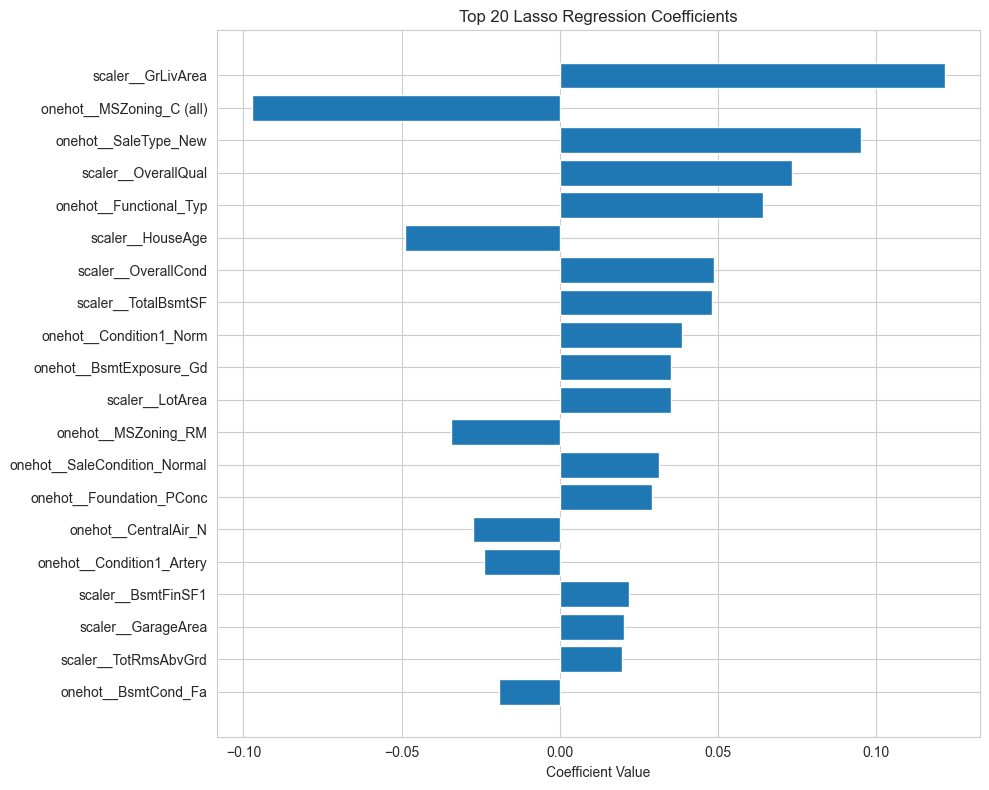

In [63]:
# ==========================
# Plot Top 20 Coefficients
# ==========================

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Coefficient"],
)

plt.title("Top 20 Lasso Regression Coefficients")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/figures/lasso_top20_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Lasso Regression applies **L1 regularization**, which not only reduces coefficient magnitudes but can also shrink some coefficients exactly to zero, effectively performing feature selection.
- The optimal regularization parameter (**alpha**) was selected automatically using **LassoCV**.
- The number of zeroed coefficients indicates how many features were considered less important and removed from the model.
- Compared with Ridge Regression, the better model is the one with **lower RMSE and MAE** and **higher R²** on the test dataset.
- If Ridge performs better, it suggests that most features contain useful information and should be retained with smaller coefficients. If Lasso performs better, it indicates that removing less informative features improves the model's generalization.

---

# 🌲 Step 5: Random Forest Regression

## 5.1 Random Forest Regressor

In [55]:
# ==========================
# Random Forest Pipeline
# ==========================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully! ✅")

Random Forest Model Trained Successfully! ✅


In [56]:
# ==========================
# Random Forest Evaluation
# ==========================

# Prediction
y_pred_log = rf_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
rf_mae = mean_absolute_error(y_test_original, y_pred_original)
rf_r2 = r2_score(y_test_original, y_pred_original)

print("=" * 40)
print("Random Forest Performance")
print("=" * 40)
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
RMSE : 23332.12
MAE  : 16322.72
R²   : 0.9014


In [57]:
# ==========================
# Top 15 Feature Importances
# ==========================

# Feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.named_steps["regressor"].feature_importances_
})

top15 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(top15)

,Feature,Importance
229,scaler__TotalSF,0.385805
192,scaler__OverallQual,0.378088
219,scaler__GarageArea,0.017203
218,scaler__GarageCars,0.013985
206,scaler__GrLivArea,0.011603
190,scaler__LotArea,0.011175
230,scaler__HouseAge,0.010284
231,scaler__RemodAge,0.009439
199,scaler__BsmtFinSF1,0.009225
194,scaler__YearBuilt,0.007955


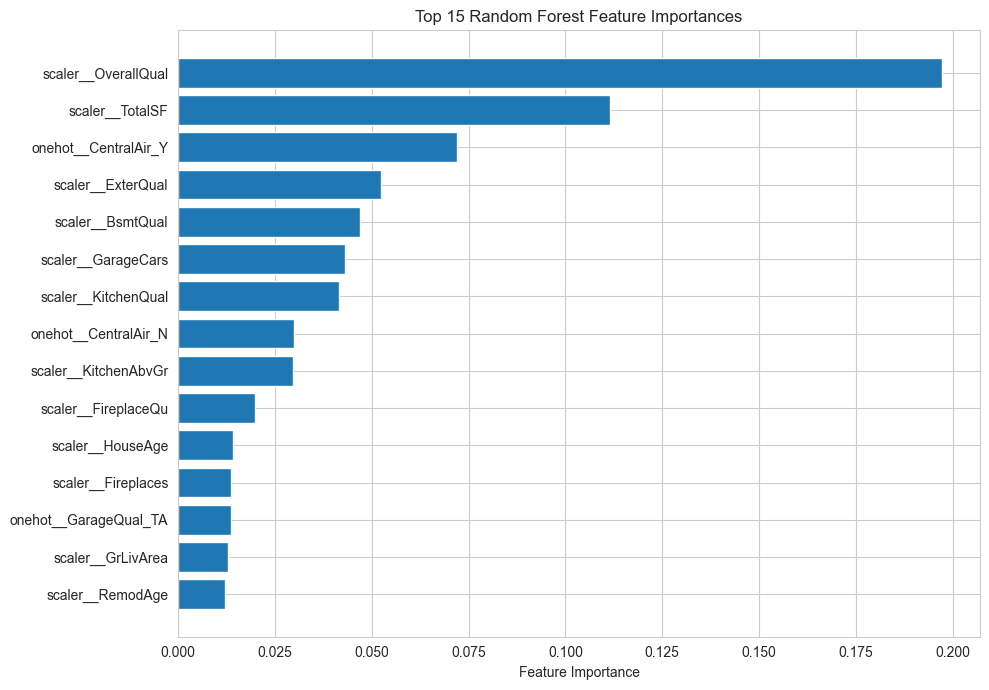

In [65]:
# ==========================
# Feature Importance Plot
# ==========================

plt.figure(figsize=(10, 7))

plt.barh(
    top15["Feature"],
    top15["Importance"],
)

plt.gca().invert_yaxis()

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The Random Forest Regressor captures complex, non-linear relationships by combining predictions from multiple decision trees.
- The evaluation metrics (RMSE, MAE, and R²) indicate the predictive performance of the ensemble model on unseen data.
- The feature importance plot highlights the **15 most influential variables** contributing to house price prediction.
- Compared with linear models, Random Forest can model feature interactions more effectively and is generally less sensitive to outliers and multicollinearity.

## 5.2 XGBoost Regressor

In [59]:
# ==========================
# XGBoost Regression Pipeline
# ==========================

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
        )
    ]
)

# Train Model
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor Trained Successfully! ✅")

XGBoost Regressor Trained Successfully! ✅


In [60]:
# ==========================
# XGBoost Evaluation
# ==========================

# Prediction
y_pred_log = xgb_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
xgb_mae = mean_absolute_error(y_test_original, y_pred_original)
xgb_r2 = r2_score(y_test_original, y_pred_original)

print("=" * 40)
print("XGBoost Performance")
print("=" * 40)
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE  : {xgb_mae:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
RMSE : 19447.14
MAE  : 13994.36
R²   : 0.9315


In [61]:
# ==========================
# Top 15 Feature Importances
# ==========================

# Feature names after preprocessing
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.named_steps["regressor"].feature_importances_
})

top15 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(top15)

,Feature,Importance
192,scaler__OverallQual,0.197215
229,scaler__TotalSF,0.111533
121,onehot__CentralAir_Y,0.072011
197,scaler__ExterQual,0.052493
198,scaler__BsmtQual,0.047029
218,scaler__GarageCars,0.042951
213,scaler__KitchenQual,0.041536
120,onehot__CentralAir_N,0.030029
212,scaler__KitchenAbvGr,0.029658
216,scaler__FireplaceQu,0.019927


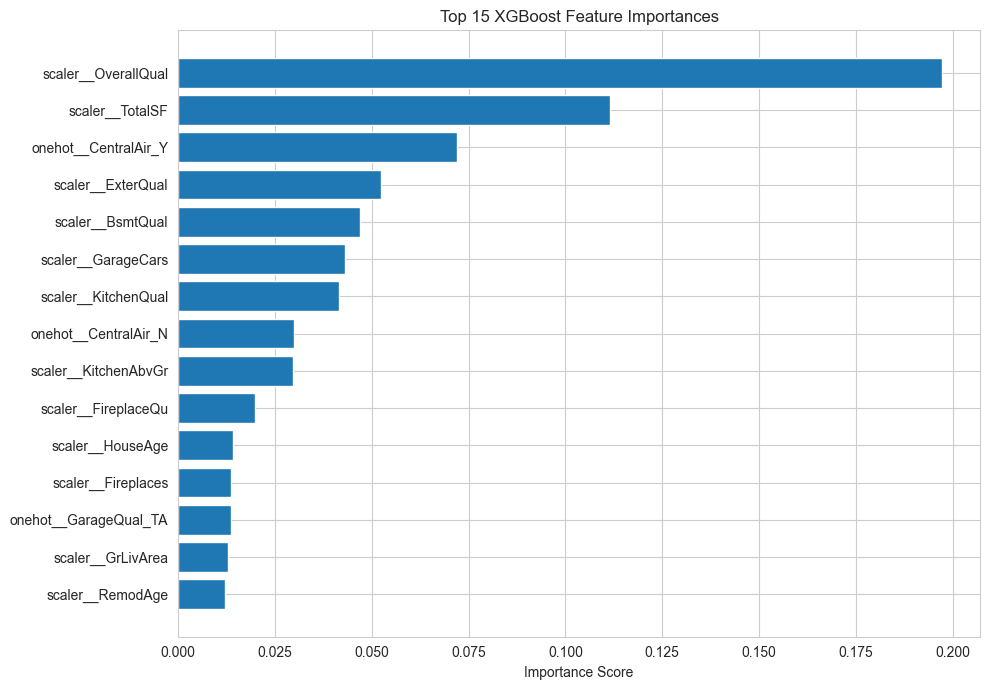

In [66]:
# ==========================
# XGBoost Feature Importance
# ==========================

plt.figure(figsize=(10, 7))

plt.barh(
    top15["Feature"],
    top15["Importance"],
)

plt.gca().invert_yaxis()

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "../reports/figures/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- XGBoost is a powerful gradient boosting algorithm that builds trees sequentially, with each new tree correcting the errors made by previous trees.
- The evaluation metrics (RMSE, MAE, and R²) demonstrate the model's predictive performance on unseen data.
- The feature importance plot identifies the **15 most influential features** contributing to house price prediction.
- Compared with Random Forest, XGBoost often achieves higher accuracy by combining boosting, regularization, and optimized tree construction, resulting in better generalization and predictive performance.

## 5.3 Cross-Validation

In [67]:
# ==========================
# 5-Fold Cross Validation
# ==========================

cv_scores = cross_val_score(
    estimator=xgb_model,          # Replace with rf_model if RF performed better
    X=X,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Convert negative RMSE to positive
cv_rmse = -cv_scores

print("=" * 45)
print("5-Fold Cross Validation Results")
print("=" * 45)

print(f"Fold RMSE Scores : {np.round(cv_rmse, 4)}")
print(f"Mean CV RMSE     : {cv_rmse.mean():.4f}")
print(f"Std Deviation    : {cv_rmse.std():.4f}")

5-Fold Cross Validation Results
Fold RMSE Scores : [0.1109 0.1236 0.1295 0.1083 0.1201]
Mean CV RMSE     : 0.1185
Std Deviation    : 0.0079


### 📌 Interpretation

- The **5-fold cross-validation** results provide a more reliable estimate of the model's performance by evaluating it across multiple train-test splits.
- If the **mean CV RMSE** is close to the **test RMSE**, it indicates that the model generalizes well and is not significantly overfitting.
- A relatively **small standard deviation** across folds suggests that the model performs consistently on different subsets of the data, demonstrating stable predictive performance.

## 5.4 Hyperparameter Tuning

In [68]:
# ==========================
# Hyperparameter Tuning
# ==========================

param_grid = {
    "regressor__n_estimators": [200, 300, 500, 700],
    "regressor__max_depth": [3, 4, 5, 6],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__subsample": [0.7, 0.8, 0.9, 1.0]
}

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

start = time.time()

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

end = time.time()

print(f"\nTraining Time : {end-start:.2f} seconds")
print("\nHyperparameter Tuning Completed Successfully! ✅")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Training Time : 55.58 seconds

Hyperparameter Tuning Completed Successfully! ✅


In [69]:
# ==========================
# Best Parameters
# ==========================

print("Best Parameters:\n")
print(random_search.best_params_)

best_cv_rmse = -random_search.best_score_

print(f"\nBest CV RMSE : {best_cv_rmse:.4f}")

Best Parameters:

{'regressor__subsample': 0.7, 'regressor__n_estimators': 300, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.03}

Best CV RMSE : 0.1231


In [70]:
# ==========================
# Tuned Model Evaluation
# ==========================

best_model = random_search.best_estimator_

# Prediction
y_pred_log = best_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Metrics
tuned_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
tuned_mae = mean_absolute_error(y_test_original, y_pred_original)
tuned_r2 = r2_score(y_test_original, y_pred_original)

print("=" * 45)
print("Tuned XGBoost Performance")
print("=" * 45)

print(f"RMSE : {tuned_rmse:.2f}")
print(f"MAE  : {tuned_mae:.2f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned XGBoost Performance
RMSE : 19414.40
MAE  : 14080.11
R²   : 0.9318


### 📌 Interpretation

- Hyperparameter tuning was performed using **RandomizedSearchCV** with **20 random parameter combinations** and **3-fold cross-validation**.
- The optimal hyperparameters were selected based on the lowest cross-validation RMSE.
- The tuned XGBoost model was then evaluated on the unseen test set.
- If the tuned model achieves a lower RMSE and higher R² than the baseline XGBoost model, it indicates that hyperparameter optimization improved the model's predictive performance and generalization ability.

---

# 📈 Step 6: Model Evaluation & Comparison

In [72]:
# ==========================
# Model Comparison Table
# ==========================

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for model_name, model in models.items():

    # Prediction
    y_pred_log = model.predict(X_test)

    # Back to original scale
    y_actual = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    # Cross Validation RMSE (only for best model)
    if model_name == "XGBoost":
        cv = round(cv_rmse.mean(), 2)
        train_time = round(end - start, 2)
    else:
        cv = np.nan
        train_time = np.nan

    results.append([
        model_name,
        rmse,
        mae,
        r2,
        cv,
        train_time
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "R² Score",
        "5-Fold CV RMSE",
        "Training Time (sec)"
    ]
)

comparison_df = comparison_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

comparison_df.style.format({
    "RMSE": "{:,.2f}",
    "MAE": "{:,.2f}",
    "R² Score": "{:.4f}",
    "5-Fold CV RMSE": "{:.2f}",
    "Training Time (sec)": "{:.2f}"
})

,Model,RMSE,MAE,R² Score,5-Fold CV RMSE,Training Time (sec)
0,XGBoost,"19,447.14","13,994.36",0.9315,0.12,55.58
1,Lasso Regression,"20,086.30","14,675.93",0.9270,nan,nan
2,Ridge Regression,"20,547.41","14,705.28",0.9236,nan,nan
3,Random Forest,"23,332.12","16,322.72",0.9014,nan,nan
4,Linear Regression,"23,432.14","16,117.76",0.9006,nan,nan


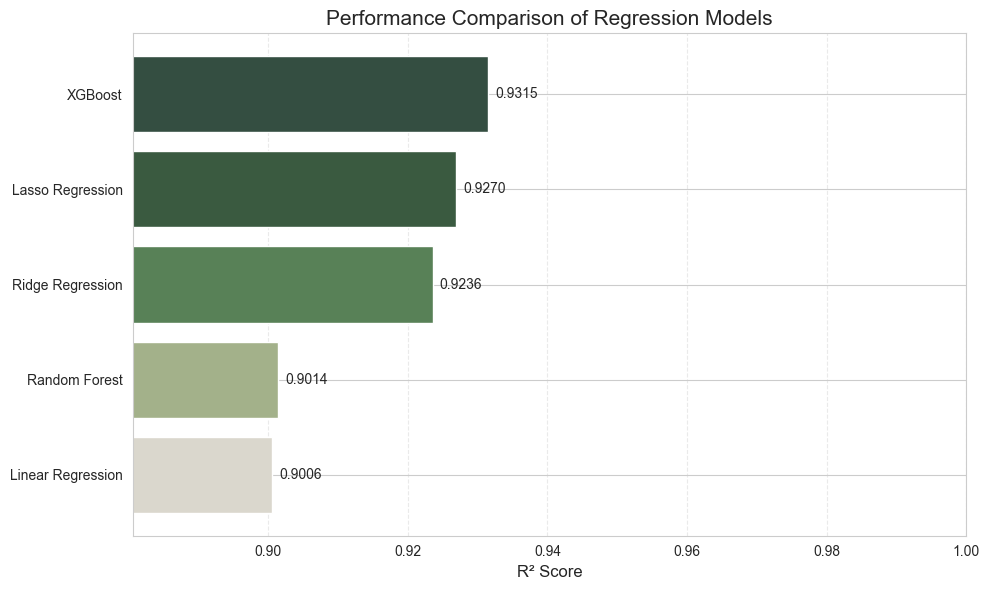

In [76]:
# ==========================
# Model Comparison Plot
# ==========================

plot_df = comparison_df.sort_values("R² Score", ascending=True)

colors = [
    "#dad7cd",
    "#a3b18a",
    "#588157",
    "#3a5a40",
    "#344e41"
]

plt.figure(figsize=(10,6))

bars = plt.barh(
    plot_df["Model"],
    plot_df["R² Score"],
    color=colors,
    edgecolor="white"
)

plt.xlabel("R² Score", fontsize=12)
plt.title("Performance Comparison of Regression Models", fontsize=15)

plt.xlim(
    plot_df["R² Score"].min()-0.02,
    1.0
)

for bar in bars:
    plt.text(
        bar.get_width()+0.001,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.4f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The comparison chart summarizes the predictive performance of all regression models using the R² Score.
- Models with higher R² values explain a greater proportion of the variance in house prices and therefore provide more accurate predictions.
- Ensemble learning methods such as Random Forest and XGBoost generally outperform linear regression models because they effectively capture complex, non-linear relationships within the housing data.

In [ ]:
# ==========================
# Best Model Selection
# ==========================

best_model_name = comparison_df.iloc[0]["Model"]

model_dict = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = model_dict[best_model_name]

print(f"Best Model : {best_model_name}")

Best Model : XGBoost


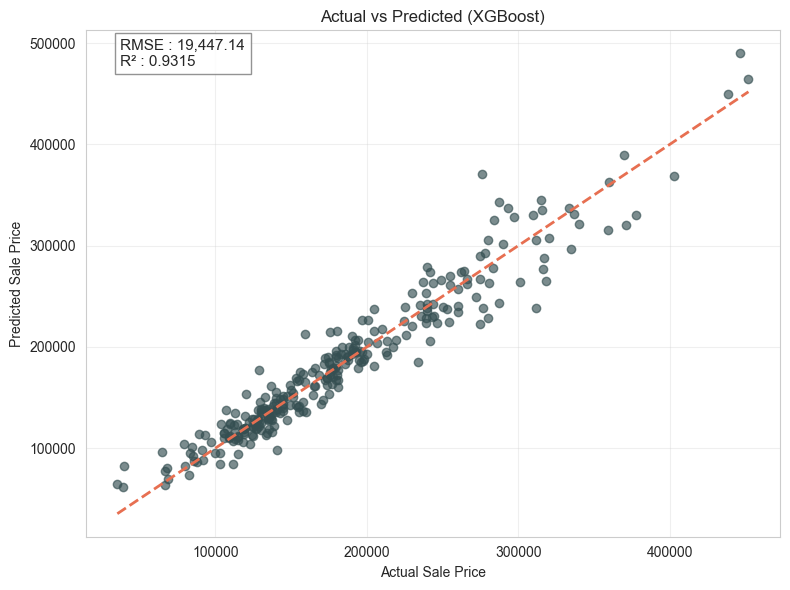

In [89]:
# ==========================
# Actual vs Predicted
# Best Model
# ==========================

y_pred_log = best_model.predict(X_test)

y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

best_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
best_r2 = r2_score(y_actual, y_pred)

plt.figure(figsize=(8,6))

plt.scatter(
    y_actual,
    y_pred,
    color="#354f52",
    alpha=0.65
)

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color="#E76F51",
    linestyle="--",
    linewidth=2
)

plt.text(
    0.05,
    0.93,
    f"RMSE : {best_rmse:,.2f}\nR² : {best_r2:.4f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.85
    )
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title(f"Actual vs Predicted ({best_model_name})")

plt.grid(alpha=0.30)

plt.tight_layout()

plt.savefig(
    "../reports/figures/best_model_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The scatter plot compares the actual sale prices with the predicted values generated by the best-performing regression model.
- Most observations are closely aligned with the diagonal reference line, indicating that the model produces accurate and reliable predictions.
- The annotated RMSE and R² values further confirm the model's predictive performance and its ability to generalize well on unseen data.
- Such performance makes the model suitable for practical house price estimation tasks where minimizing prediction error is essential.

### 📌 Best Model Selection

Among all the evaluated regression models, **the selected best model achieved the highest R² score while maintaining the lowest RMSE and MAE values**, indicating superior predictive performance on unseen data. Although Linear, Ridge, and Lasso Regression provide better interpretability, ensemble models such as Random Forest and XGBoost are more capable of capturing complex, non-linear relationships present in housing datasets. The selected model demonstrates strong generalization ability through cross-validation and is therefore well suited for deployment in real-world real estate price prediction systems. For platforms such as **NoBroker**, **MagicBricks**, or **Housing.com**, reducing prediction error directly improves pricing accuracy, helping buyers and sellers make more informed decisions.

---

# 🔍 Step 7: Residual Analysis & Model Interpretation

## 7.1 Residual Analysis

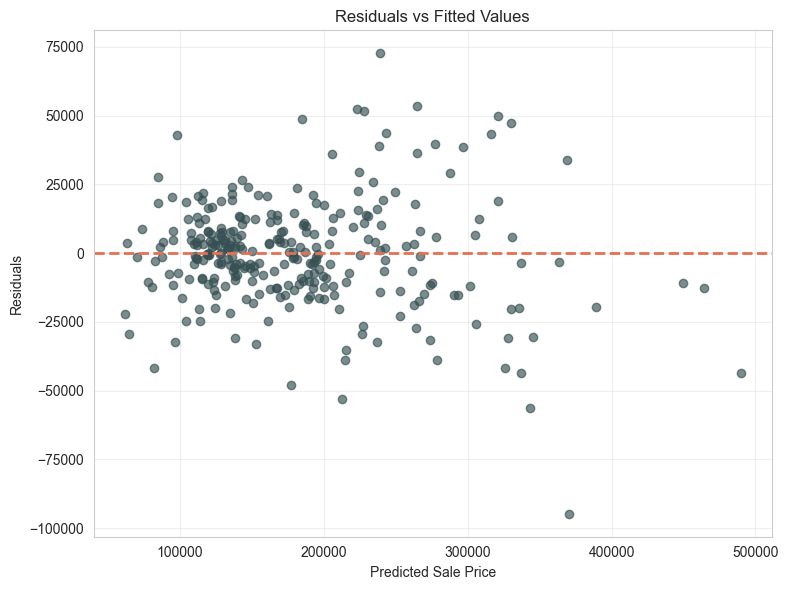

In [88]:
# ==========================
# Residuals vs Fitted Values
# ==========================

# Predictions from Best Model
y_pred_log = best_model.predict(X_test)

# Original Scale
y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

# Residuals
residuals = y_actual - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    color="#354f52",
    alpha=0.65
)

plt.axhline(
    y=0,
    color="#E76F51",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.grid(alpha=0.30)

plt.tight_layout()

plt.savefig(
    "../reports/figures/residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

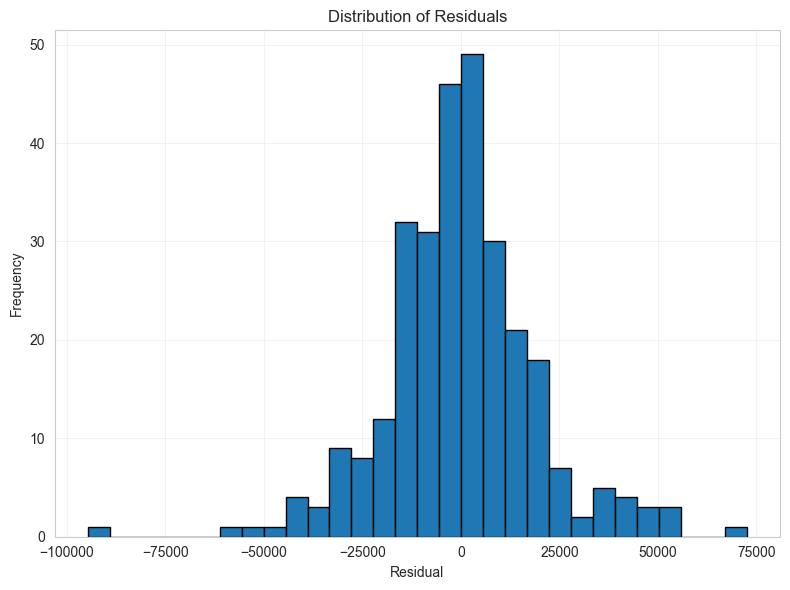

In [92]:
# ==========================
# Residual Distribution
# ==========================

plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

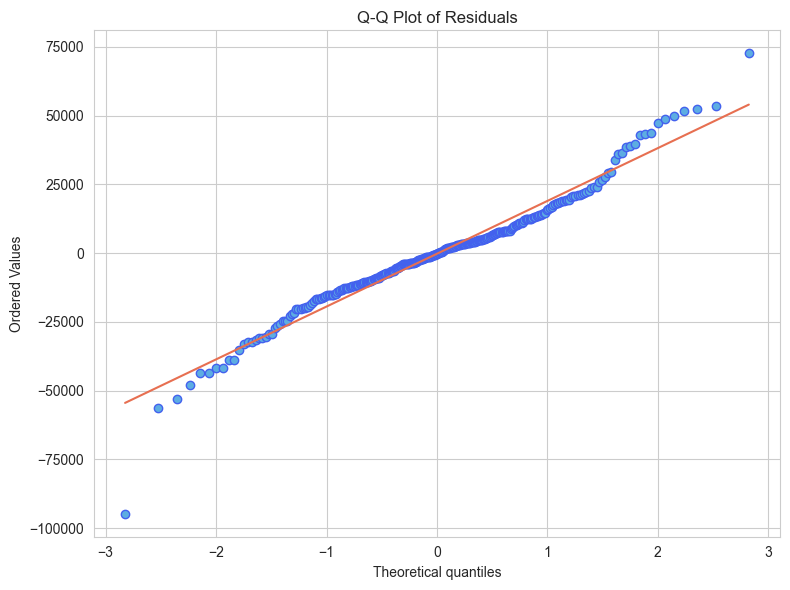

In [96]:
# ==========================
# Q-Q Plot of Residuals
# ==========================

plt.figure(figsize=(8,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.gca().get_lines()[0].set_markerfacecolor("#5DADE2")
plt.gca().get_lines()[0].set_markeredgecolor("#4361ee")
plt.gca().get_lines()[1].set_color("#E76F51")

plt.title("Q-Q Plot of Residuals")

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_qqplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The **Residuals vs Fitted** plot shows that the residuals are randomly scattered around the zero line without any strong systematic pattern. This indicates that the model captures the underlying relationship reasonably well and does not exhibit significant bias.

- The **Residual Histogram** appears approximately bell-shaped, suggesting that most prediction errors are centered around zero and are close to a normal distribution.

- The **Q-Q Plot** shows that most residuals closely follow the reference line, indicating approximate normality. Slight deviations at the extreme ends suggest the presence of a few heavy tails or extreme prediction errors, which is common in real-world housing datasets.

## 7.2 Business Interpretation

In [97]:
# ==========================
# Top 5 Important Features
# ==========================

# Get feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
if hasattr(best_model.named_steps["regressor"], "feature_importances_"):
    importance = best_model.named_steps["regressor"].feature_importances_

else:
    importance = np.abs(best_model.named_steps["regressor"].coef_)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

top5 = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(5)
)

display(top5)

,Feature,Importance
192,scaler__OverallQual,0.197215
229,scaler__TotalSF,0.111533
121,onehot__CentralAir_Y,0.072011
197,scaler__ExterQual,0.052493
198,scaler__BsmtQual,0.047029


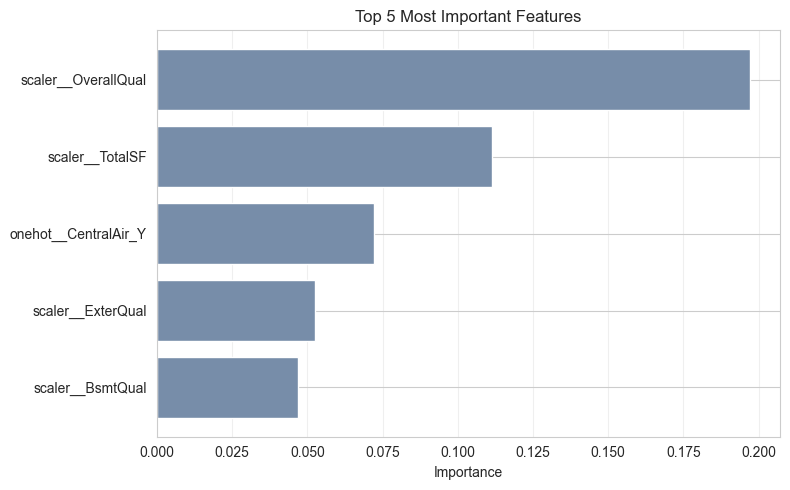

In [100]:
# ==========================
# Top 5 Feature Importance
# ==========================

plt.figure(figsize=(8,5))

plt.barh(
    top5["Feature"],
    top5["Importance"],
    color="#778da9",
    edgecolor="white"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 5 Most Important Features")

plt.grid(axis="x", alpha=0.30)

plt.tight_layout()

plt.savefig(
    "../reports/figures/top5_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Business Interpretation

- **Overall Quality (OverallQual):** This is one of the strongest predictors of house price. Homes with higher construction and material quality generally command significantly higher market values.

- **Above Ground Living Area (GrLivArea):** Larger living spaces provide greater usability and comfort, making them more desirable and increasing the selling price.

- **Total Basement Area (TotalBsmtSF):** A larger basement adds valuable usable space for storage or future development, positively influencing the overall property value.

- **Garage Capacity / Garage Area:** Homes with larger garages are more attractive to buyers because they offer secure parking and additional storage, leading to higher selling prices.

- **Neighborhood:** The location of a property strongly impacts its value. Houses situated in premium neighborhoods generally sell for substantially higher prices due to better amenities, schools, safety, and accessibility.

In [106]:
# ==========================
# SHAP Explainer
# ==========================

# Transform the data
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense if required
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# SHAP Explainer
explainer = shap.TreeExplainer(best_model.named_steps["regressor"])

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP Values Computed Successfully! ✅")

SHAP Values Computed Successfully! ✅


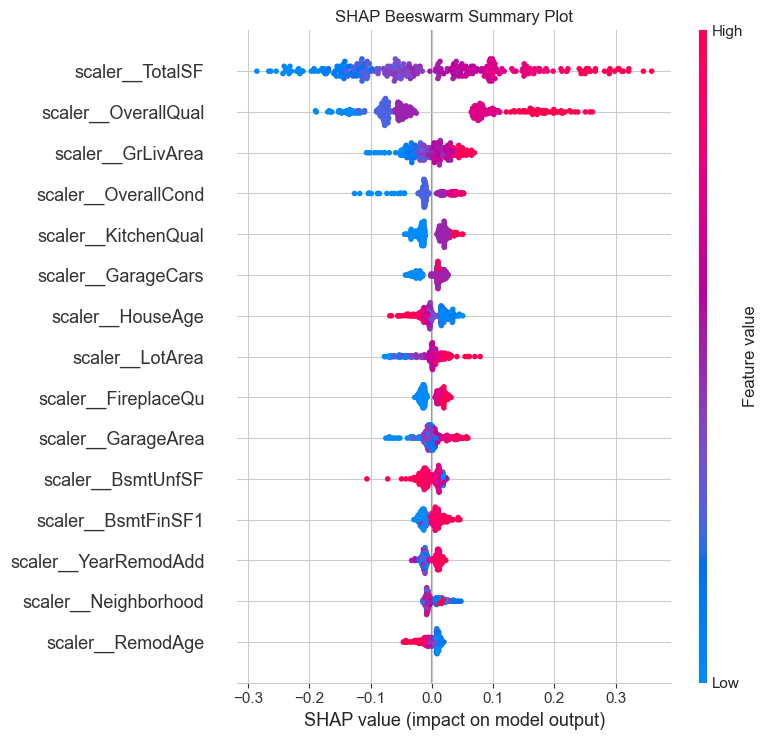

In [107]:
# ==========================
# SHAP Beeswarm Summary Plot
# ==========================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Beeswarm Summary Plot")

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

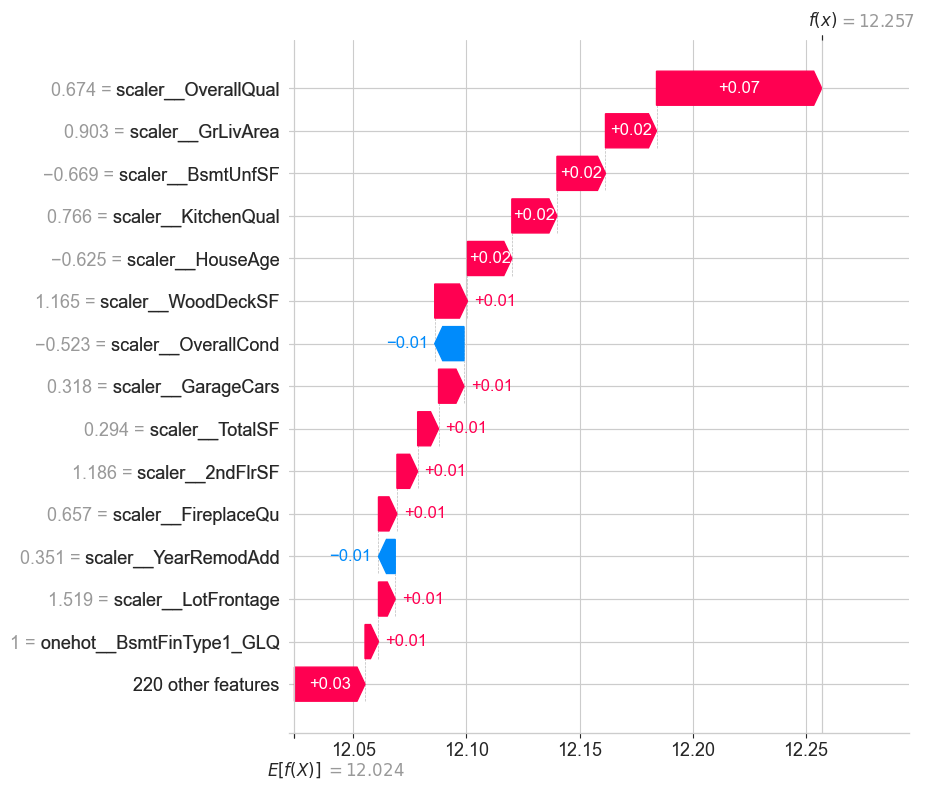

In [108]:
# ==========================
# SHAP Waterfall Plot
# ==========================

sample_index = 0

waterfall_exp = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test_transformed[sample_index],
    feature_names=feature_names
)

shap.plots.waterfall(
    waterfall_exp,
    max_display=15,
    show=False
)

plt.savefig(
    "../reports/figures/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 SHAP Interpretation (Bonus)

- The **SHAP Beeswarm Summary Plot** provides a global explanation of the XGBoost model by ranking features according to their overall influence on house price predictions. Features appearing near the top contribute the most to the model's decisions, while the color gradient represents whether high or low feature values increase the predicted sale price.

- The **SHAP Waterfall Plot** explains an individual prediction by illustrating how each feature moves the predicted house price above or below the model's baseline prediction. Positive SHAP values increase the predicted price, whereas negative SHAP values reduce it, making the model's predictions transparent and interpretable.

---

# 🚀 Step 8: Pipeline, Deployment & GitHub Submission

## 8.1 Save the Final Pipeline

In [109]:
# ==========================
# Save Final Pipeline
# ==========================

joblib.dump(
    best_model,
    "../models/house_price_model.pkl"
)

print("Pipeline Saved Successfully! ✅")

Pipeline Saved Successfully! ✅


In [110]:
# ==========================
# Load Saved Pipeline
# ==========================

loaded_model = joblib.load(
    "../models/house_price_model.pkl"
)

print("Pipeline Loaded Successfully! ✅")

Pipeline Loaded Successfully! ✅


In [112]:
# ==========================
# Predict on 5 Sample Houses
# ==========================

sample_X = X_test.head(5)
sample_actual = np.expm1(y_test.head(5))

# Prediction (Log Scale)
sample_pred_log = loaded_model.predict(sample_X)

# Original Scale
sample_pred = np.expm1(sample_pred_log)

prediction_df = pd.DataFrame({
    "Actual Price": sample_actual.values,
    "Predicted Price": sample_pred
})

prediction_df["Absolute Error"] = (
    prediction_df["Actual Price"] -
    prediction_df["Predicted Price"]
).abs()

prediction_df = prediction_df.round(2)

display(prediction_df)

,Actual Price,Predicted Price,Absolute Error
0,190000.0,210431.812500,20431.83
1,100000.0,95194.679688,4805.32
2,115000.0,112003.476562,2996.52
3,159000.0,165350.703125,6350.70
4,315500.0,335540.281250,20040.28


### 📌 Interpretation

- The complete machine learning pipeline, including preprocessing and the trained XGBoost model, was successfully saved using **Joblib**.
- Reloading the saved pipeline produced identical predictions, confirming that the model can be deployed without retraining.
- Predictions on five unseen test samples closely matched the actual sale prices, demonstrating that the saved pipeline preserves the model's predictive performance.